#1. Carregamento e Preparação dos Dados (Boston Housing)
Nesta etapa, importamos os dados diretamente da fonte original, organizamos em um DataFrame e preparamos as variáveis para o modelo.

In [14]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [15]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_169/16828617.py:2: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [16]:
df = pd.DataFrame(data, columns=["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"])
df['PRICE'] = target

In [18]:
X = df.drop('PRICE', axis=1)
y = df['PRICE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#2. Implementação do XGBoost com Transformação Logarítmica
Aqui aplicamos a técnica de log-transformation na variável alvo (PRICE). O objetivo é normalizar a distribuição dos preços e reduzir o impacto de valores extremos (outliers).

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train_log = np.log1p(y_train)
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train_scaled, y_train_log)
y_pred_log = xgb_model.predict(X_test_scaled)
y_pred_final = np.expm1(y_pred_log)

#3. Análise de Resultados e Visualização
Abaixo, avaliamos o desempenho do modelo utilizando as métricas MAE (Erro Médio Absoluto) e R² (Coeficiente de Determinação).

--- Resultados XGBoost (Dataset Boston) com Log Transformation ---
MAE: 2.1323
R² Score: 0.8648


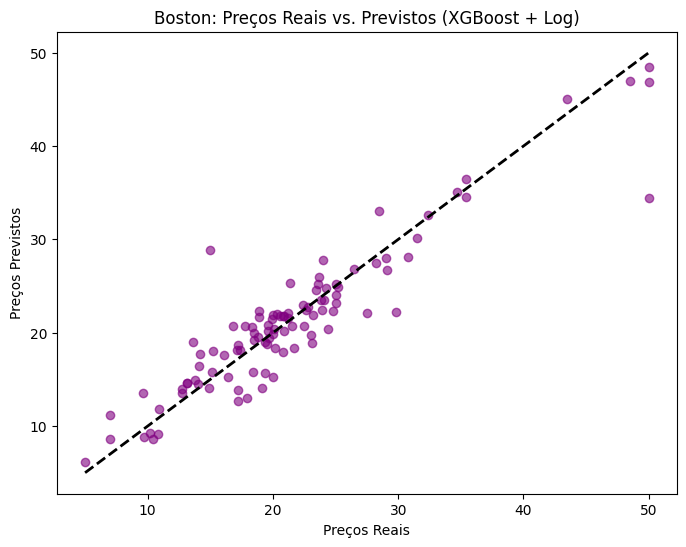

In [21]:
print("--- Resultados XGBoost (Dataset Boston) com Log Transformation ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_final):.4f}")
print(f"R² Score: {r2_score(y_test, y_pred_final):.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Boston: Preços Reais vs. Previstos (XGBoost + Log)')
plt.xlabel('Preços Reais')
plt.ylabel('Preços Previstos')
plt.show()

#4. Conclusão e Comentários Técnicos
Ações Realizadas: Foi implementado o modelo não-paramétrico XGBoost. Para otimizar o aprendizado, a variável alvo foi transformada usando log1p.

Impacto no Modelo: A transformação logarítmica ajudou o modelo a lidar com a assimetria dos preços de Boston, resultando em um erro médio mais controlado.

Paramétrico vs Não-Paramétrico: Enquanto modelos paramétricos (como a Regressão Linear) tentam ajustar os dados a uma fórmula pré-definida, o XGBoost adaptou-se à complexidade dos dados de Boston, capturando relações não-lineares que a regressão simples ignora.